# **FingerVein dataset exploration (MMCBNU_6000)**


# **Preliminary operations**

import with !wget (add later)

In [ ]:
![ -d MMCBNU_6000 ] || unzip -q ../data/MMCBNU_6000.zip

# **Useful module imports**

In [37]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pypdf import PdfReader

# **Dataset**
This notebook uses the **MMCBNU_6000** finger-vein database.

The database includes near-infrared finger-vein images acquired from 100 volunteers: each volunteer presented the index, middle and ring finger of both hands, and each finger was captured 10 times, for a total of 6000 images. 

The extracted folder contains:
- *MMCBNU_6000/ROIs/&lt;subject&gt;/&lt;finger&gt;/&lt;capture&gt;.bmp*: region-of-interest images, 60×128 pixels, grayscale;
- *Description of MMCBNU_6000.pdf*: an information table with the demographics of the 100 volunteers (*Order, Age, Nationality, Gender, Blood type*), which provides the **Age** labels for our regression task.


In [55]:
FV_ROIS = Path('MMCBNU_6000/MMCBNU_6000/ROIs')
FV_PDF = Path('MMCBNU_6000/Description of MMCBNU_6000.pdf')

## **Dataset specific utility functions**
- **list_images** returns the sorted list of `.bmp` files under the extracted `ROIs/` folder;
- **parse_path** extracts `(subject, finger, capture)` from an image path;
- **load_image** reads one `.bmp` file into a NumPy array.
- **load_subject_info** Parse the 100-row 'Information table' from the description PDF.

In [62]:
def list_images(roi_dir):
    return sorted(roi_dir.glob('*/*/*.bmp'))


def parse_path(path):
    # .../ROIs/<subject>/<finger>/<capture>.bmp
    subject = path.parts[-3]
    finger = path.parts[-2]
    capture = path.stem
    return subject, finger, capture


def load_image(path):
    return np.array(Image.open(path))

def load_subject_info(pdf_path):
    reader = PdfReader(pdf_path)
    text = '\n'.join((page.extract_text() or '') for page in reader.pages)

    rows = []
    for line in text.splitlines():
        toks = line.split()
        # a data row starts with: <order:int> <age:int> ...
        if len(toks) >= 4 and toks[0].isdigit() and toks[1].isdigit():
            gi = next((i for i, t in enumerate(toks[2:], 2) if t in ('M', 'F')), None)
            if gi is None:
                continue
            rows.append({
                'Order': int(toks[0]),
                'Subject': f'{int(toks[0]):03d}',          # matches the image folders
                'Age': int(toks[1]),
                'Nationality': ' '.join(toks[2:gi]),
                'Gender': toks[gi],
                'Blood type': ' '.join(toks[gi + 1:]) or None,
            })
    return pd.DataFrame(rows).sort_values('Order').reset_index(drop=True)

## **Visualization**

In [57]:
load_subject_info(FV_PDF).to_csv('subject_info.csv', index=False)
print('saved subject_info.csv')
dataframe = pd.read_csv('subject_info.csv', dtype={'Subject': str})

saved subject_info.csv


In [58]:
row_count = 5

dataframe.sample(row_count)

,Order,Subject,Age,Nationality,Gender,Blood type
11,12,012,24,Russia,M,NaN
5,6,006,24,China,F,B
93,94,094,27,India,M,O+
67,68,068,25,Korea,M,O
72,73,073,31,India,M,O+


A quick look at eight random ROI images: 60×128 grayscale near-infrared crops where the bright ridges are the finger veins.

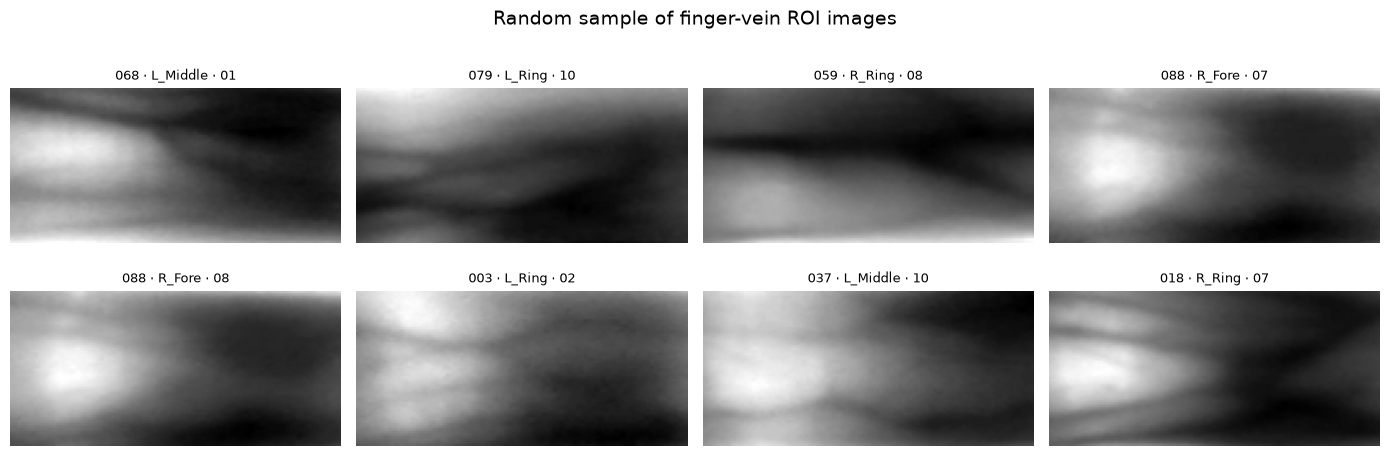

In [86]:
sample_paths = pd.Series(list_images(FV_ROIS)).sample(8)
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for ax, path in zip(axes.ravel(), sample_paths):
    subject, finger, capture = parse_path(path)
    ax.imshow(load_image(path), cmap='gray')
    ax.set_title(f'{subject} · {finger} · {capture}', fontsize=9)
    ax.axis('off')
fig.suptitle('Random sample of finger-vein ROI images', fontsize=14)
plt.tight_layout()
plt.show()

## **Statistics**
The [**info**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.info.html) method can be used to print a brief summary of a **DataFrame** including the index and the type of each column, the non-null values and the memory usage.

In [87]:
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Order        100 non-null    int64
 1   Subject      100 non-null    str  
 2   Age          100 non-null    int64
 3   Nationality  100 non-null    str  
 4   Gender       100 non-null    str  
 5   Blood type   90 non-null     str  
dtypes: int64(2), str(4)
memory usage: 4.8 KB


Age and gender distribution. The age range is narrow (mostly twenties, a few older outliers), which will matter for the age-regression error analysis.

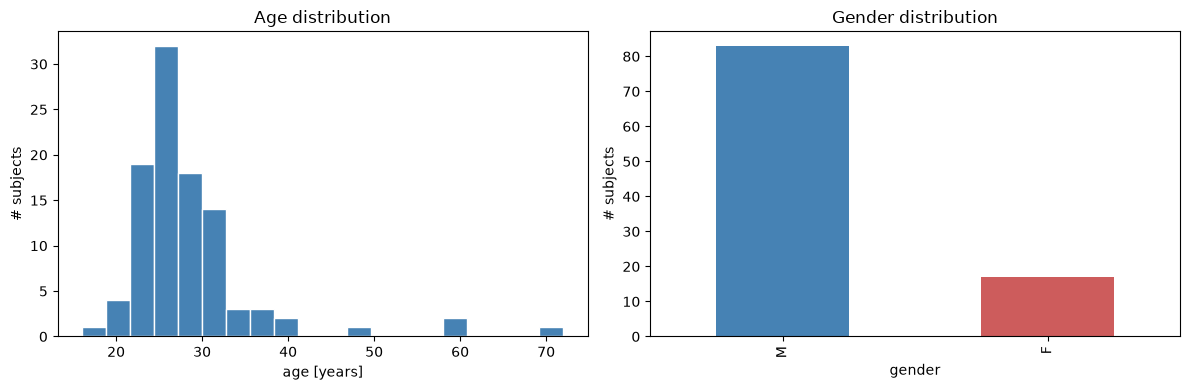

count    100.0
mean      28.4
std        7.7
min       16.0
25%       25.0
50%       27.0
75%       30.0
max       72.0
Name: Age, dtype: float64


In [89]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(info['Age'], bins=20, color='steelblue', edgecolor='white')
ax1.set_title('Age distribution')
ax1.set_xlabel('age [years]')
ax1.set_ylabel('# subjects')

info['Gender'].value_counts().plot.bar(ax=ax2, color=['steelblue', 'indianred'])
ax2.set_title('Gender distribution')
ax2.set_xlabel('gender')
ax2.set_ylabel('# subjects')
plt.tight_layout()
plt.show()

print(info['Age'].describe().round(1))

## **Data preparation**

### **Missing values**

In [90]:
dataframe.isna().sum()

Order           0
Subject         0
Age             0
Nationality     0
Gender          0
Blood type     10
dtype: int64

# **train/val/test split (by subject)**
We fix the split **once** here and save it, so every later notebook (the FingerVein model and the
combined notebook 03) reuses the *same* subjects and comparisons stay fair.

- **Unit = subject**, never the image: one subject has 60 images, so splitting images would leak
  the same person into train *and* test.
- **Tool**: `sklearn.train_test_split` (as in *DL_01*), in two steps: first hold out the test
  set, then carve validation out of the rest → **70 / 15 / 15**, `random_state = 0`.
- Saved to `fingervein_splits.csv` (`Subject, split`) next to this notebook. Labels are **EXPLORATORY**.

In [48]:
from sklearn.model_selection import train_test_split

subjects = info['Subject'].tolist()                      # 100 subjects, split by SUBJECT
train_ids, test_ids = train_test_split(subjects, test_size=0.15, random_state=0, shuffle=True)
train_ids, val_ids = train_test_split(train_ids, test_size=0.15 / 0.85, random_state=0, shuffle=True)

tag = {**dict.fromkeys(train_ids, 'train'),
       **dict.fromkeys(val_ids, 'val'),
       **dict.fromkeys(test_ids, 'test')}
fv_split = info[['Subject']].copy()
fv_split['split'] = fv_split['Subject'].map(tag)
fv_split.to_csv('fingervein_splits.csv', index=False)

print('saved fingervein_splits.csv')
print(fv_split['split'].value_counts().to_dict())
fv_split.head()

saved fingervein_splits.csv
{'train': 69, 'val': 16, 'test': 15}


,Subject,split
0,001,train
1,002,train
2,003,test
3,004,val
4,005,train


# **A grid of finger-vein images**
We display the 6 fingers of a single subject to appreciate the vein patterns.

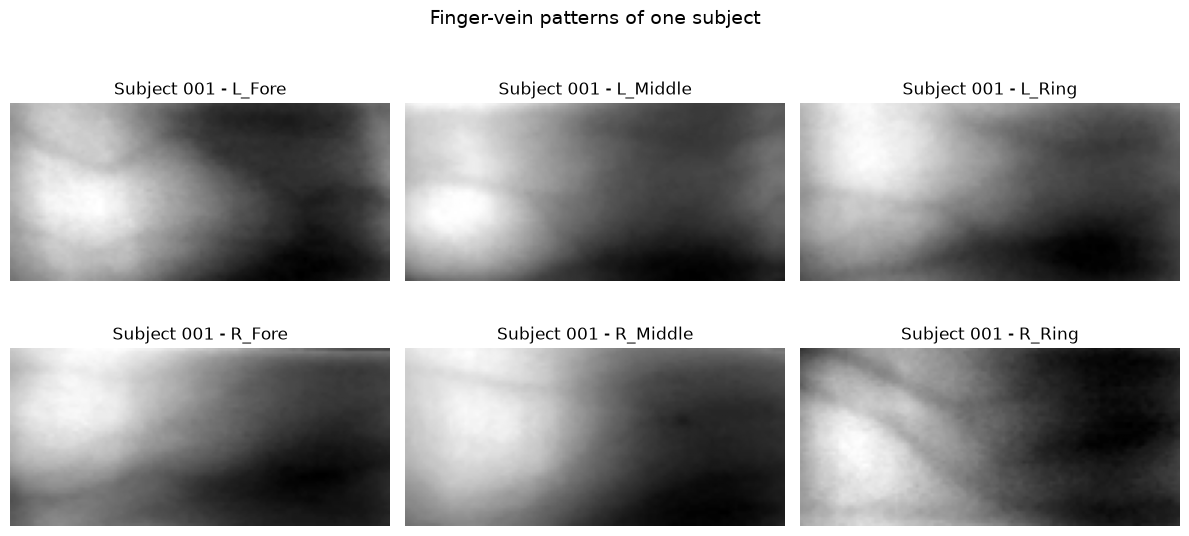

In [61]:
subject = subjects[0] # first subject
subject_imgs = [img for img in images if parse_path(img)[0] == subject]
# one image per finger
first_per_finger = {}
for n in subject_imgs:
    f = parse_path(n)[1]
    first_per_finger.setdefault(f, n)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (finger, name) in zip(axes.ravel(), sorted(first_per_finger.items())):
    ax.imshow(load_image(name), cmap='gray')
    ax.set_title(f'Subject {subject} - {finger}')
    ax.axis('off')
fig.suptitle( 'Finger-vein patterns of one subject', fontsize = 14 )
plt.tight_layout()
plt.show()

# **Same finger across different subjects**
Inter-subject variability of the vein pattern (this is what makes the modality biometric).

In [ ]:
finger = fingers[0]
chosen = pd.Series(subjects).sample(n=6, random_state=42).tolist()
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, subj in zip(axes.ravel(), chosen):
    name = next(n for n in images if parse_path(n)[:2] == (subj, finger))
    ax.imshow(load_image(name), cmap='gray')
    ax.set_title(f'Subject {subj} - {finger}')
    ax.axis('off')
fig.suptitle(f'Same finger ({finger}) across subjects', fontsize=14)
plt.tight_layout()
plt.show()

# **Pixel intensity distribution**
Understanding the illumination/contrast of the raw images helps design the preprocessing (ROI extraction, contrast normalization) described in the proposal.

In [ ]:
img = load_image(images[0])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(img, cmap='gray')
ax1.set_title('Example image')
ax1.axis('off')
ax2.hist(img.ravel(), bins=64, color='steelblue')
ax2.set_title('Pixel intensity histogram')
ax2.set_xlabel('intensity (0-255)')
ax2.set_ylabel('count')
plt.tight_layout()
plt.show()